## 3. Analisi del Dataset Iris

In [1]:
%conda install pandas
%conda install matplotlib
%conda install seaborn

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


1. Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)

In [12]:
# Creo un dataframe con le specie e qanti campioni ci sono per specie
species_count_df = df['species'].value_counts().reset_index()
species_count_df

,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


2. Calcola la lunghezza e la larghezza media dei petali per specie

In [16]:
petals_mean_dims = df.groupby('species')[['petal_width', 'petal_length']].mean().reset_index()
petals_mean_dims

,species,petal_width,petal_length
0,setosa,0.246,1.462
1,versicolor,1.326,4.260
2,virginica,2.026,5.552


3. Visualizza le dimensioni dei petali per specie (scatterplot)

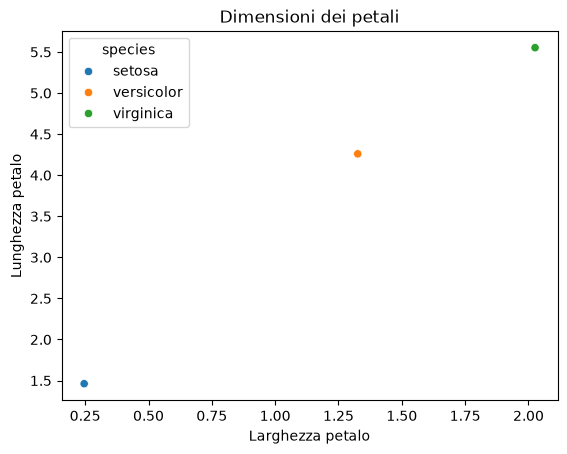

In [26]:
sns.scatterplot(
    data=petals_mean_dims, 
    x='petal_width',
    y='petal_length',
    hue='species',
)
plt.title('Dimensioni dei petali')
plt.xlabel('Larghezza petalo')
plt.ylabel('Lunghezza petalo')
plt.show()

4. Crea una nuova colonna per l'area del petalo e analizzala

In [27]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [31]:
# Creo una series per l'area moltiplicando i valori di length e width
petal_area = df['petal_length'] * df['petal_width']

# Aggiungo la colonna al dataframe
df['petal_area'] = petal_area
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_area
0,5.1,3.5,1.4,0.2,setosa,0.28
1,4.9,3.0,1.4,0.2,setosa,0.28
2,4.7,3.2,1.3,0.2,setosa,0.26
3,4.6,3.1,1.5,0.2,setosa,0.30
4,5.0,3.6,1.4,0.2,setosa,0.28


In [35]:
# Analizzo i dati dell'area del petalo divisi per specie
area_analysis = df.groupby('species')['petal_area'].describe().reset_index()

,species,count,mean,std,min,25%,50%,75%,max
0,setosa,50.0,0.3656,0.181155,0.11,0.2800,0.300,0.42,0.96
1,versicolor,50.0,5.7204,1.368403,3.30,4.8600,5.615,6.75,8.64
2,virginica,50.0,11.2962,2.157412,7.50,9.7175,11.445,12.79,15.87


5. Grafico della distribuzione dell'area del petalo per specie (boxplot)

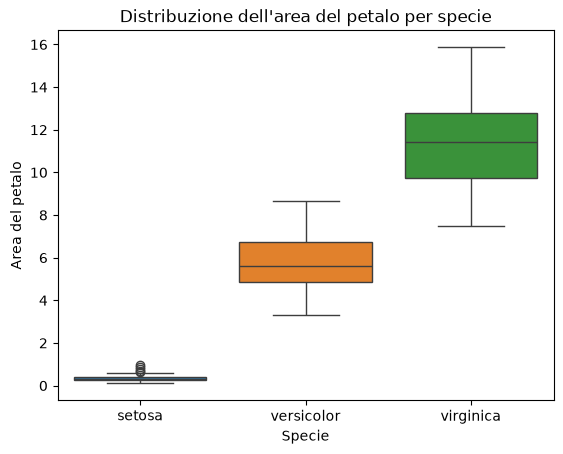

In [47]:
sns.boxplot(data=df, x='species', y='petal_area', hue='species')
plt.title('Distribuzione dell\'area del petalo per specie')
plt.xlabel('Specie')
plt.ylabel('Area del petalo')
plt.show()